In [ ]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

1. Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(url)

# 2. EDA and Data Analysis


In [ ]:
print(df.shape)
df.head()

(19535, 6)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


In [26]:
df.duplicated().sum()

np.int64(0)

This dataset has no null values and no duplicate values


# 3. Descriptive Statistics

In [ ]:
df.describe(include="all")

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


In [ ]:
df.median()

,0
Engine rpm,746.000000
Lub oil pressure,3.162035
Fuel pressure,6.201720
Coolant pressure,2.166883
lub oil temp,76.817350
Coolant temp,78.346662


# 4. Data Visualization

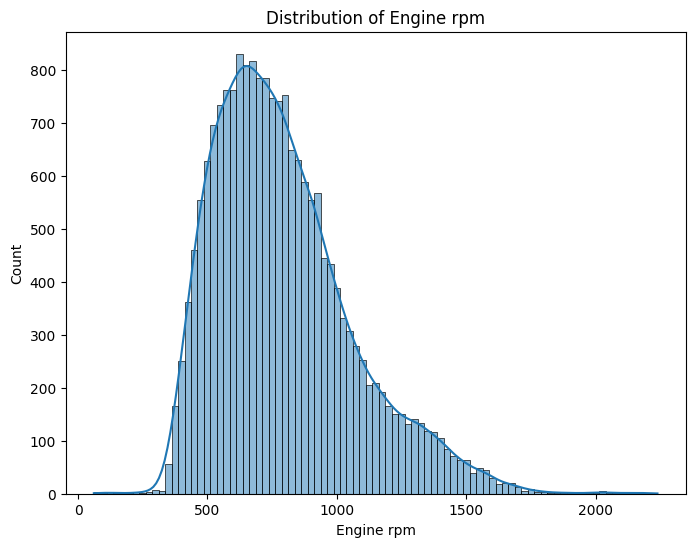

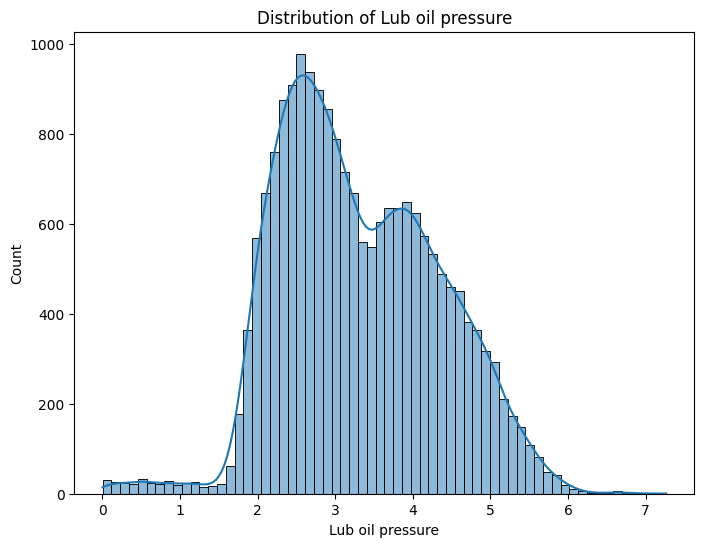

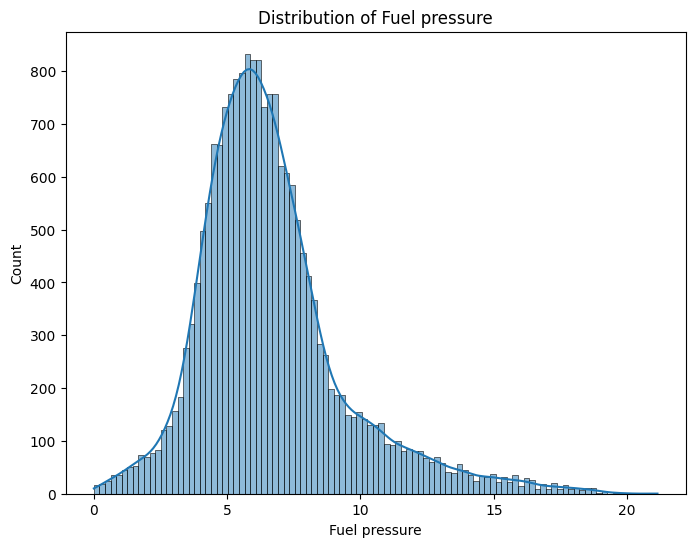

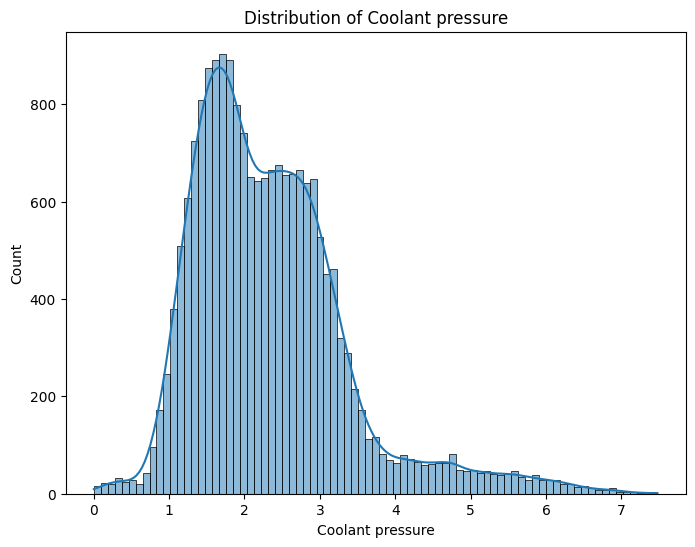

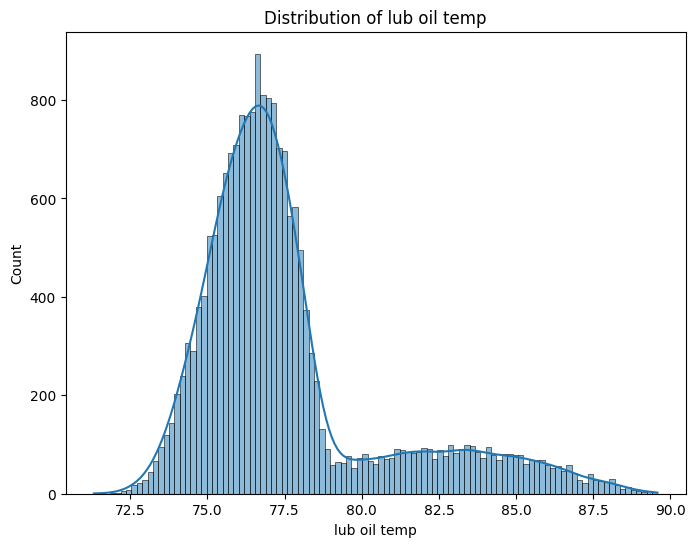

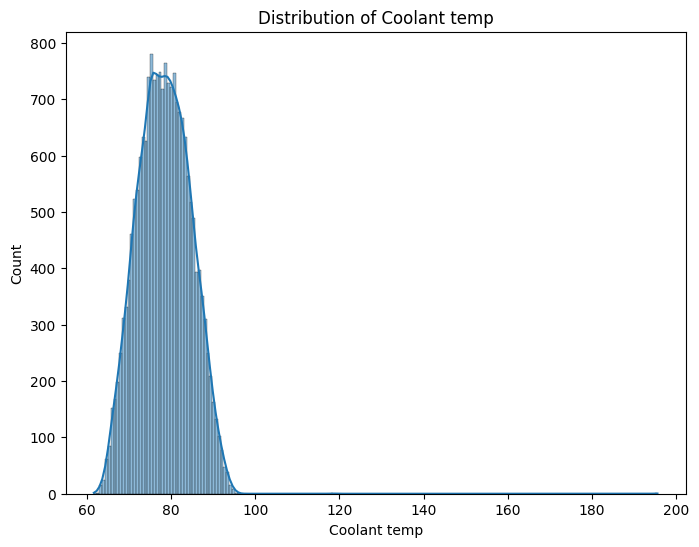

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#histograms
for feature in df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

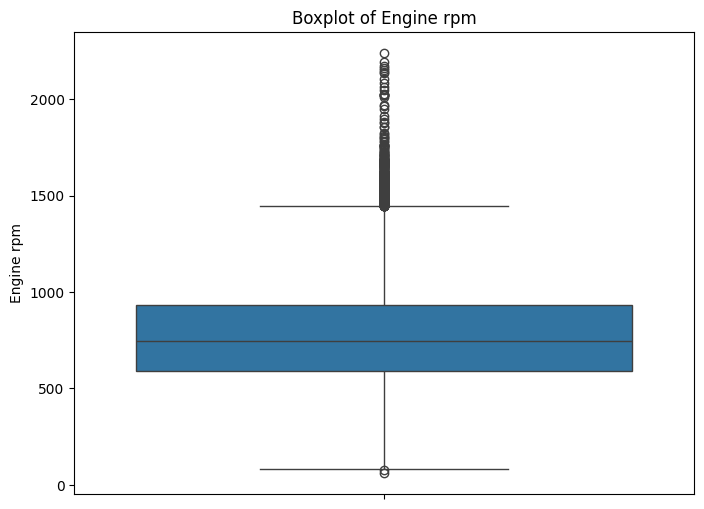

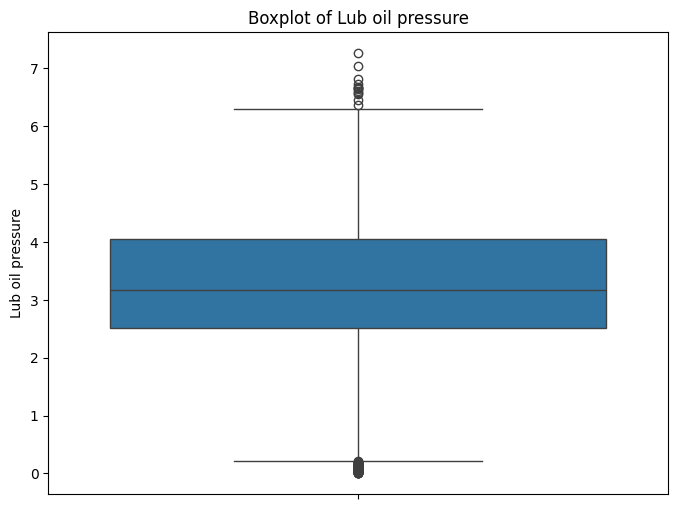

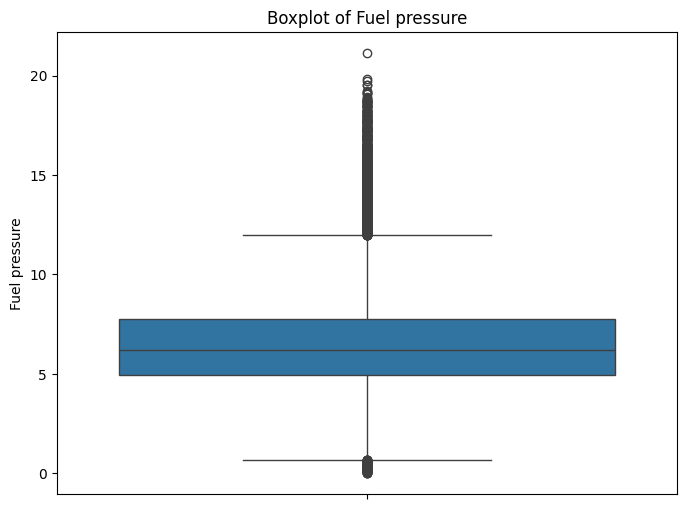

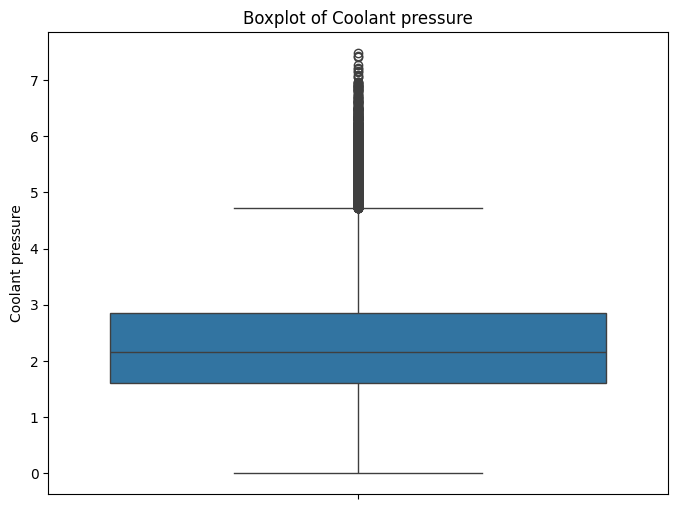

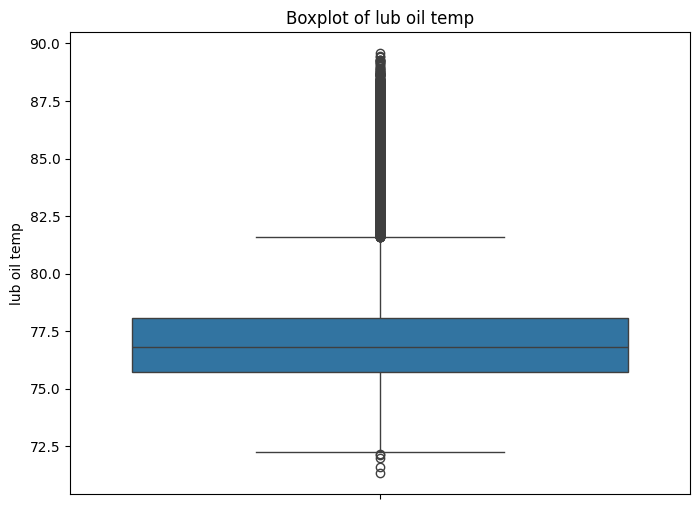

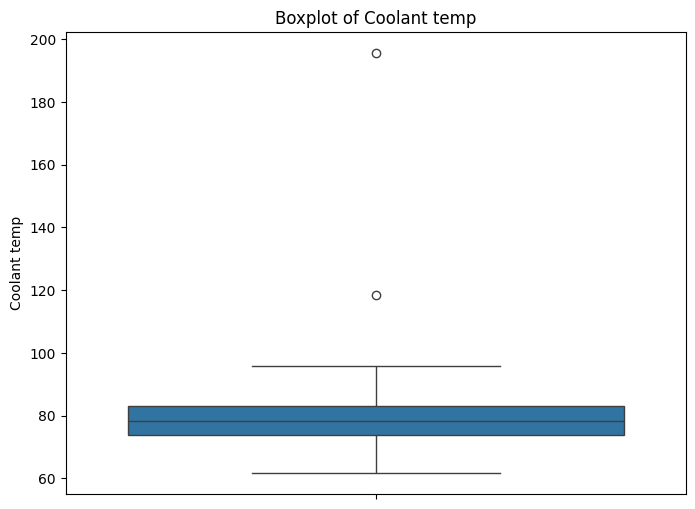

In [ ]:
for feature in df.columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(df[feature])
  plt.title(f"Boxplot of {feature}")

These features seem to be normally distributed but all seems to be skewed to the right, meaning there are extreme values that are significantly larger than the mean. The mean is greater than the median in this distribution.

Surprisingly, there are not a lot of outliers for coolant temperature. Just ones that skew the distribution quite a bit.

# 5. Anomaly Detection with IQR

In [ ]:
#IQR method for outlier detection for each feature

#loop through each feature and sort the values in ascending order
for feature in df.columns:
  sortedDf = df[feature].sort_values()
  print(sortedDf)
  print(sortedDf.shape)

115        61
12325      77
8117       84
13267     107
8829      129
         ... 
9275     2151
10506    2163
13191    2172
7790     2191
15932    2239
Name: Engine rpm, Length: 19535, dtype: int64
(19535,)
12799    0.003384
17443    0.004214
17395    0.007891
8442     0.012157
14986    0.013606
           ...   
11950    6.681497
1807     6.729324
6525     6.826921
17991    7.051322
3186     7.265566
Name: Lub oil pressure, Length: 19535, dtype: float64
(19535,)
7456      0.003187
17345     0.012640
11272     0.027141
14028     0.029335
8520      0.045126
           ...    
561      19.510172
9417     19.558918
8643     19.717281
13845    19.858917
9        21.138326
Name: Fuel pressure, Length: 19535, dtype: float64
(19535,)
12391    0.002483
5901     0.002870
17272    0.005076
7220     0.015665
18957    0.015938
           ...   
7744     7.211976
8620     7.263990
11672    7.417474
5859     7.425322
13910    7.478505
Name: Coolant pressure, Length: 19535, dtype: float64
(19535,)


In [ ]:
#calculate the quantiles
dfIQR = df.copy()

for feature in dfIQR.columns:
  Q1 = dfIQR[feature].quantile(0.25)
  Q3 = dfIQR[feature].quantile(0.75)
  IQR = Q3 - Q1
  #establish bounds
  upper = Q3 + 1.5 * IQR
  lower = Q1 - 1.5 * IQR
  dfIQR[f"{feature}_outlier"] = ((dfIQR[feature] > upper) | (dfIQR[feature] < lower)).astype('int')
  print(f"Q1 for {feature}: {Q1}")
  print(f"Q3 for {feature}: {Q3}")
  print(f"IQR for {feature}: {IQR}")
  print(f"upper bound for {feature}: {upper}")
  print(f"lower bound for {feature}: {lower}")

Q1 for Engine rpm: 593.0
Q3 for Engine rpm: 934.0
IQR for Engine rpm: 341.0
upper bound for Engine rpm: 1445.5
lower bound for Engine rpm: 81.5
Q1 for Lub oil pressure: 2.5188147159999996
Q3 for Lub oil pressure: 4.0552715195
IQR for Lub oil pressure: 1.5364568035000001
upper bound for Lub oil pressure: 6.35995672475
lower bound for Lub oil pressure: 0.21412951074999942
Q1 for Fuel pressure: 4.916886097
Q3 for Fuel pressure: 7.7449733335
IQR for Fuel pressure: 2.8280872365
upper bound for Fuel pressure: 11.987104188250001
lower bound for Fuel pressure: 0.6747552422499998
Q1 for Coolant pressure: 1.6004658630000002
Q3 for Coolant pressure: 2.848839661
IQR for Coolant pressure: 1.2483737979999998
upper bound for Coolant pressure: 4.7214003579999995
lower bound for Coolant pressure: -0.27209483399999956
Q1 for lub oil temp: 75.72599023000001
Q3 for lub oil temp: 78.071690565
IQR for lub oil temp: 2.3457003349999894
upper bound for lub oil temp: 81.59024106749999
lower bound for lub oil te

In [ ]:
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [ ]:
dfIQR.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0


In [ ]:
outlierCols = [f'{feature}_outlier' for feature in dfIQR.columns if f'{feature}_outlier' in dfIQR.columns]
dfIQR['outlierCount'] = dfIQR[outlierCols].sum(axis=1)

nSamples = len(dfIQR)

bestThreshold = None
for threshold in range(1, len(outlierCols)+1):
  nOutliers = (dfIQR['outlierCount'] >= threshold).sum()
  outlierPercentage = (nOutliers / nSamples) * 100
  flag = "within 1-5%" if 1 <= outlierPercentage <= 5 else "outside 1-5%"
  print(f"    {threshold}     |   {nOutliers:6d}   |  {outlierPercentage:.2f}%{flag}")
  if bestThreshold is None and 1 <= outlierPercentage <= 5:
      bestThreshold = threshold

if bestThreshold:
    dfIQR['is_outlier'] = (dfIQR['outlierCount'] >= bestThreshold).astype(int)
    finalPct = (dfIQR['is_outlier'].sum() / nSamples) * 100
    print(f"\nChosen threshold: {bestThreshold} feature(s) simultaneously in outlier condition")
    print(f"Total outliers flagged: {dfIQR['is_outlier'].sum()} ({finalPct:.2f}%)")
else:
    print("\nNo single threshold achieved 1-5% — consider adjusting your IQR multiplier")

    1     |     4636   |  23.73%outside 1-5%
    2     |      422   |  2.16%within 1-5%
    3     |       11   |  0.06%outside 1-5%
    4     |        0   |  0.00%outside 1-5%
    5     |        0   |  0.00%outside 1-5%
    6     |        0   |  0.00%outside 1-5%

Chosen threshold: 2 feature(s) simultaneously in outlier condition
Total outliers flagged: 422 (2.16%)


Through looping through the different thresholds with the condition for threshold in range(1, len(outlierCols)+1), we have found that two features as outliers will achieve the desired effect of having an outlier percentage of 1-5%.

# 6. Anomaly Detection with ML models

6.a One-class SVM

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

#scale data
dfSVM = df.copy()

scaler = StandardScaler()
scaledData = scaler.fit_transform(dfSVM)

model=OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)
model.fit(scaledData)

yPred = model.predict(scaledData)
print(yPred)

[ 1 -1  1 ...  1  1  1]


In [ ]:
dfSVM['anomaly'] = yPred
dfSVM

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1
...,...,...,...,...,...,...,...
19530,681,3.598792,7.300853,1.083391,76.206955,69.848780,1
19531,580,2.243040,5.242489,1.471350,76.884907,87.098119,1
19532,616,3.310048,3.787693,6.001031,75.889810,72.220009,1
19533,1163,2.731726,3.703595,2.951684,76.784626,81.400088,1


In [ ]:
anomalies = dfSVM[dfSVM.anomaly == -1]

print(anomalies.shape)
anomalies

(1043, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1
9,806,3.946885,21.138326,1.572569,74.923316,72.112692,-1
17,1312,5.963439,7.563578,5.931953,77.738876,88.661972,-1
25,957,2.922171,4.281125,0.263216,74.332290,77.981410,-1
35,1374,2.543575,8.641020,1.541131,82.268575,66.810303,-1
...,...,...,...,...,...,...,...
19418,1536,4.775813,10.211842,2.118696,81.400970,83.649940,-1
19433,986,2.929212,14.431486,4.985264,75.477519,69.808798,-1
19467,1320,2.269715,14.557006,1.447439,75.620339,74.135266,-1
19501,450,0.699888,4.111952,0.949993,74.869050,72.889809,-1


In [ ]:
#adjust to get 1-5% value for outliers
nSamples = len(scaledData)

validNus = []

bestNu = None
for nu in [round(x * 0.01, 2) for x in range(1, 21)]:
  m = OneClassSVM(kernel='rbf', gamma=0.5, nu=nu)
  m.fit(scaledData)
  yPred = m.predict(scaledData)
  nOutliers = (yPred == -1).sum()
  outlierPercentage = (nOutliers / nSamples) * 100
  flag = "within 1-5%" if 1 <= outlierPercentage <= 5 else "outside 1-5%"
  print(f"{nu:.2f}  |   {nOutliers:6d}   |  {outlierPercentage:.2f}%{flag}")
  if 1 <= outlierPercentage <= 5:
    validNus.append(nu)

bestNu = max(validNus)
print(f"\nChosen nu: {bestNu} (maximum within 1-5% range)")

model = OneClassSVM(kernel='rbf', gamma=0.5, nu=bestNu)
model.fit(scaledData)
yPred = model.predict(scaledData)
finalPct = (yPred == -1).sum() / nSamples * 100
print(f"Total outliers flagged: {yPred[yPred == -1].shape[0]} ({finalPct:.2f}%)")

0.01  |      611   |  3.13%within 1-5%
0.02  |      627   |  3.21%within 1-5%
0.03  |      737   |  3.77%within 1-5%
0.04  |      858   |  4.39%within 1-5%
0.05  |     1043   |  5.34%outside 1-5%
0.06  |     1218   |  6.23%outside 1-5%
0.07  |     1404   |  7.19%outside 1-5%
0.08  |     1594   |  8.16%outside 1-5%
0.09  |     1789   |  9.16%outside 1-5%
0.10  |     1984   |  10.16%outside 1-5%
0.11  |     2160   |  11.06%outside 1-5%
0.12  |     2342   |  11.99%outside 1-5%
0.13  |     2532   |  12.96%outside 1-5%
0.14  |     2744   |  14.05%outside 1-5%
0.15  |     2936   |  15.03%outside 1-5%
0.16  |     3139   |  16.07%outside 1-5%
0.17  |     3321   |  17.00%outside 1-5%
0.18  |     3524   |  18.04%outside 1-5%
0.19  |     3716   |  19.02%outside 1-5%
0.20  |     3902   |  19.97%outside 1-5%

Chosen nu: 0.04 (maximum within 1-5% range)
Total outliers flagged: 858 (4.39%)


I had the option to pick the first nu that was valid or the most conservative option (highest nu that was still in range), given that ship failures could be costly, I believe the context of the question called for a more conservative nu, hence picking the max value.

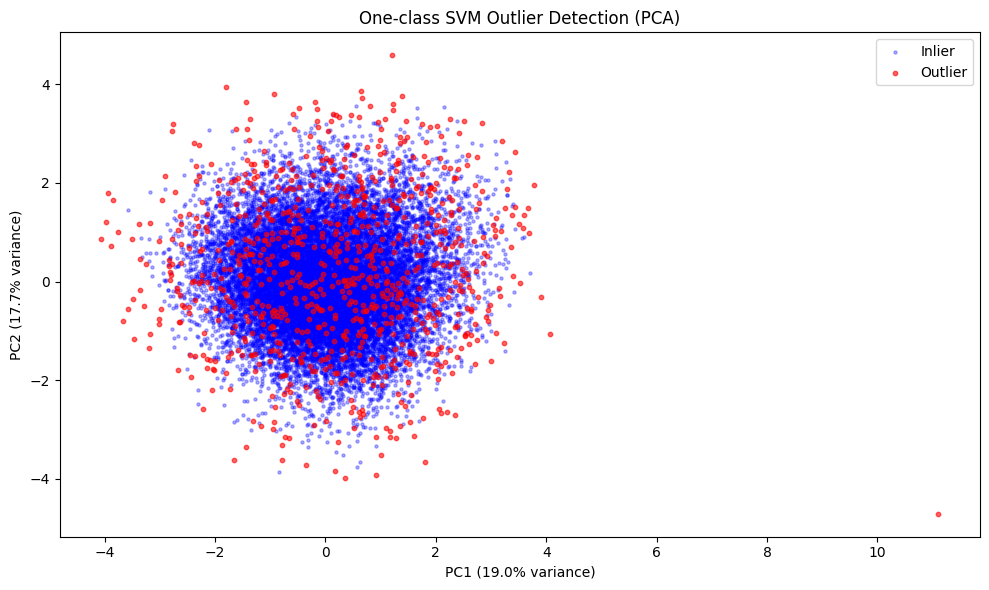

Variance explained by 2 PCs: 36.7%


In [ ]:
#Data visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pcaData = pca.fit_transform(scaledData)

inliers = pcaData[yPred == 1]
outliers = pcaData[yPred == -1]

plt.figure(figsize=(10, 6))
plt.scatter(inliers[:,0], inliers[:,1], c='blue', s=5, alpha=0.3, label='Inlier')
plt.scatter(outliers[:,0], outliers[:,1], c='red', s=10, alpha=0.6, label='Outlier')

plt.title('One-class SVM Outlier Detection (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

The variance explained is very low here, another approach is needed


6.b Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

dfIso = df.copy()

df.copy()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220
...,...,...,...,...,...,...
19530,681,3.598792,7.300853,1.083391,76.206955,69.848780
19531,580,2.243040,5.242489,1.471350,76.884907,87.098119
19532,616,3.310048,3.787693,6.001031,75.889810,72.220009
19533,1163,2.731726,3.703595,2.951684,76.784626,81.400088


In [ ]:
scaledDataIso = scaler.fit_transform(dfIso)

nSamples = len(scaledDataIso)
validContaminations=[]

for contamination in [round(x * 0.01, 2) for x in range(1, 21)]:
  iso = IsolationForest(n_estimators = 100, contamination=contamination, random_state=42)
  iso.fit(scaledDataIso)
  yPredIso = iso.predict(scaledDataIso)
  nOutliersIso = (yPredIso == -1).sum()
  outlierPercentageIso = (nOutliersIso / nSamples) * 100
  flag = "within 1-5%" if 1 <= outlierPercentageIso <= 5 else "outside 1-5%"
  print(f"{contamination:.2f}  |   {nOutliersIso:6d}  |   {outlierPercentageIso:.2f}%{flag}")
  if 1 <= outlierPercentageIso <= 5:
    validContaminations.append(contamination)

bestContamination = max(validContaminations)
print(f"\nChosen contamination: {bestContamination} (maximum within 1-5% range)")

isoModel = IsolationForest(n_estimators = 100, contamination=bestContamination, random_state=42)
isoModel.fit(scaledDataIso)
yPredIso = isoModel.predict(scaledDataIso)
dfIso['anomaly']=(yPredIso == -1).astype(int)

finalPct = (dfIso['anomaly'].sum()/nSamples) * 100
print(f"Total outliers flagged: {dfIso['anomaly'].sum()} ({finalPct:.2f}%)")

0.01  |      196  |   1.00%within 1-5%
0.02  |      391  |   2.00%within 1-5%
0.03  |      587  |   3.00%within 1-5%
0.04  |      782  |   4.00%within 1-5%
0.05  |      977  |   5.00%outside 1-5%
0.06  |     1173  |   6.00%outside 1-5%
0.07  |     1368  |   7.00%outside 1-5%
0.08  |     1563  |   8.00%outside 1-5%
0.09  |     1759  |   9.00%outside 1-5%
0.10  |     1954  |   10.00%outside 1-5%
0.11  |     2149  |   11.00%outside 1-5%
0.12  |     2345  |   12.00%outside 1-5%
0.13  |     2540  |   13.00%outside 1-5%
0.14  |     2735  |   14.00%outside 1-5%
0.15  |     2931  |   15.00%outside 1-5%
0.16  |     3126  |   16.00%outside 1-5%
0.17  |     3321  |   17.00%outside 1-5%
0.18  |     3517  |   18.00%outside 1-5%
0.19  |     3712  |   19.00%outside 1-5%
0.20  |     3907  |   20.00%outside 1-5%

Chosen contamination: 0.04 (maximum within 1-5% range)
Total outliers flagged: 782 (4.00%)


Slight difference to note here though, unlike SVM, contamination is not strict mathematical bound, rather telling the model what to expect, hence this sweep is more important here in determining the optimal parameters.

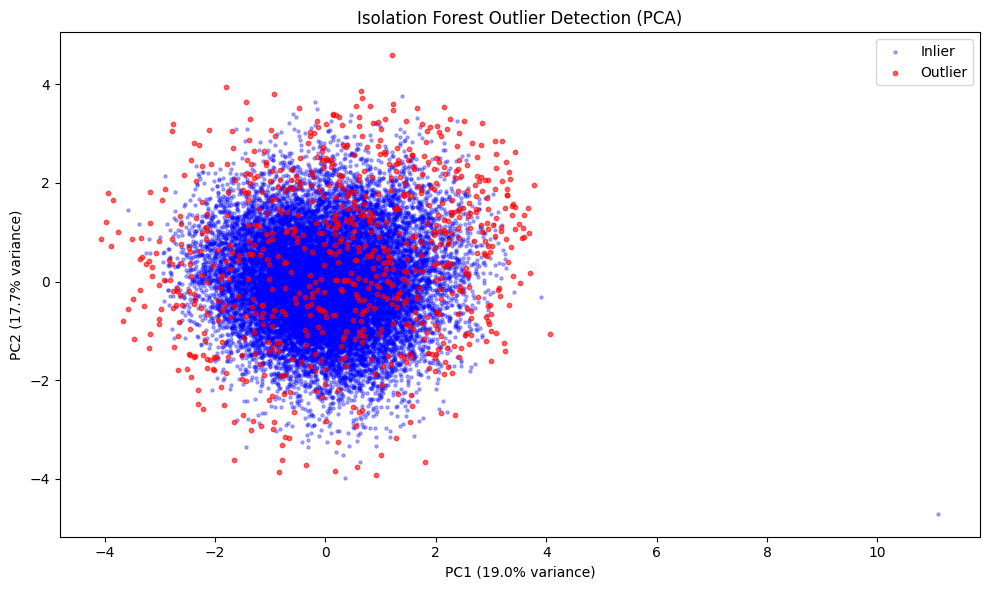

Variance explained by 2 PCs: 36.7%


In [ ]:
#pca plot for isolation forest
pca = PCA(n_components=2)
pcaData = pca.fit_transform(scaledDataIso)

inliers = pcaData[yPredIso == 1]
outliers = pcaData[yPredIso == -1]

plt.figure(figsize=(10, 6))
plt.scatter(inliers[:,0], inliers[:,1], c='blue', s=5, alpha=0.3, label='Inlier')
plt.scatter(outliers[:,0], outliers[:,1], c='red', s=10, alpha=0.6, label='Outlier')

plt.title('Isolation Forest Outlier Detection (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

The graphs looks too similar, have to plot side by side to see if there is any difference or if there is an error

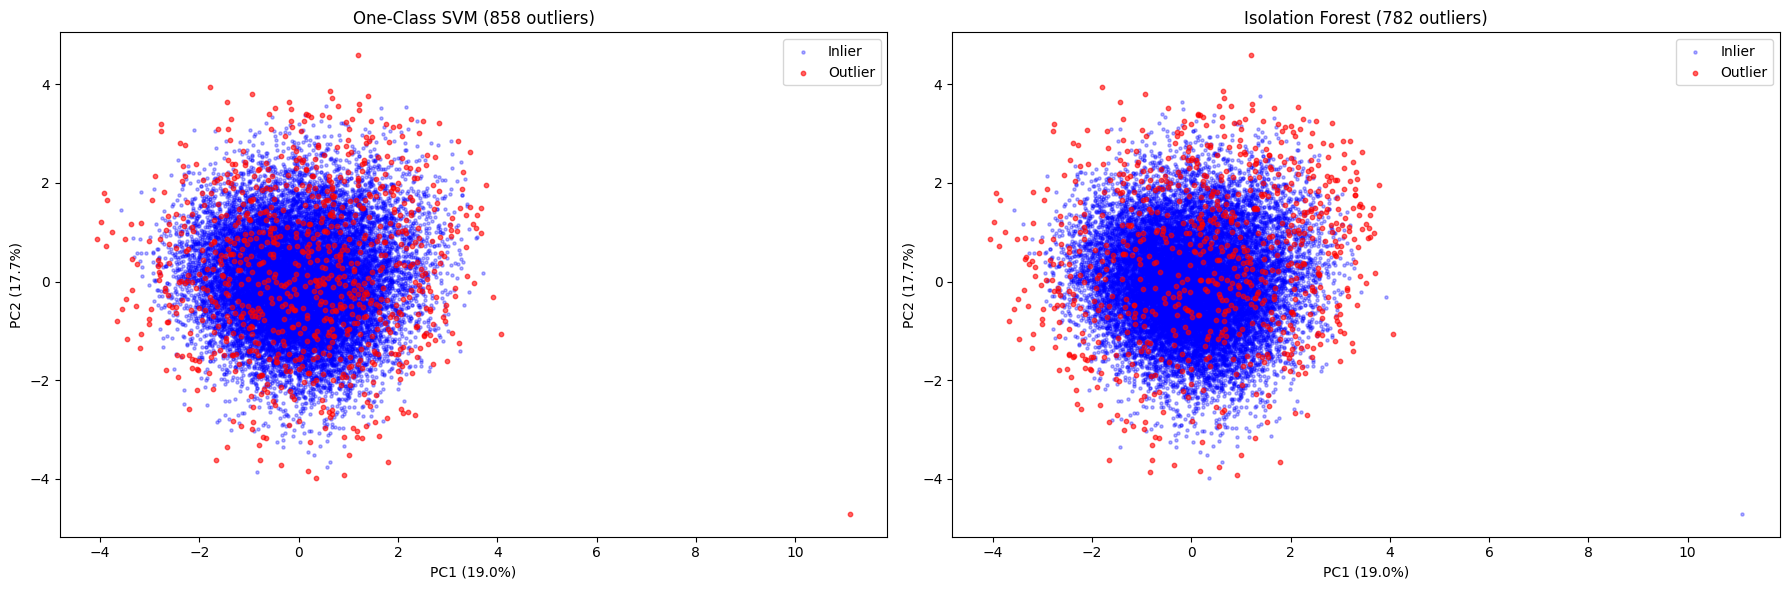

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, preds, title in zip(
    axes,
    [yPred, yPredIso],
    ['One-Class SVM', 'Isolation Forest']
):
    inliers = pcaData[preds == 1]
    outliers = pcaData[preds == -1]
    ax.scatter(inliers[:,0], inliers[:,1], c='blue', s=5, alpha=0.3, label='Inlier')
    ax.scatter(outliers[:,0], outliers[:,1], c='red', s=10, alpha=0.6, label='Outlier')
    ax.set_title(f'{title} ({(preds == -1).sum()} outliers)')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend()

plt.tight_layout()
plt.show()

The graphs looks similar, should also check if both models are flagging the same outliers. There is potentially an error if this is the case.

In [28]:
df['outlierScore'] = (yPred == -1).astype(int) + (yPredIso == -1).astype(int)

print(df['outlierScore'].value_counts().sort_index())

outlierScore
0    18335
1      760
2      440
Name: count, dtype: int64


2 means that the outlier was flagged by both models, since each being equal to -1 means one. 1 means that only one of the models flagged the outlier. This means that both models executed correctly and they they identified different sets of outliers.

There is not much difference between the methods. This is because I am using the same underlying data for both representations using the same scaler.

The difference is in the distribution of the outliers, where isolation forest identifies more outliers on the edge of the centroid where SVM's distribution is more clustered.

This makes sense since Isolation forests isolates peripheral points which are easier to identify as outliers.

However, it is clear that more rigorous testing is needed, as the explained variance for both tests is low, both at 36.7%/

# New Section

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]